# Brain tumor

|                |   |
:----------------|---|
| **Nombre**     |  Sebastian Ochoa Sanchez  |
| **Fecha**      | 06/04/2026  |
| **Expediente** | 721521  |

In [13]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder , OrdinalEncoder



In [14]:
df = pd.read_csv('brain_tumor_dataset.csv')  
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


###  Realizamos la ingeneria en caracteristicas

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

### Propocines de gender y tumor type

In [16]:
gender_proportions = df['Gender'].value_counts(normalize=True) * 100
print("Gender Proportions (%):")
print(gender_proportions)

tumor_type_proportions = df['Tumor_Type'].value_counts(normalize=True) * 100
print("\nTumor_Type Proportions (%):")
print(tumor_type_proportions)

Gender Proportions (%):
Gender
Female    50.08
Male      49.92
Name: proportion, dtype: float64

Tumor_Type Proportions (%):
Tumor_Type
Malignant    50.15
Benign       49.85
Name: proportion, dtype: float64


### histogramas de las columnas

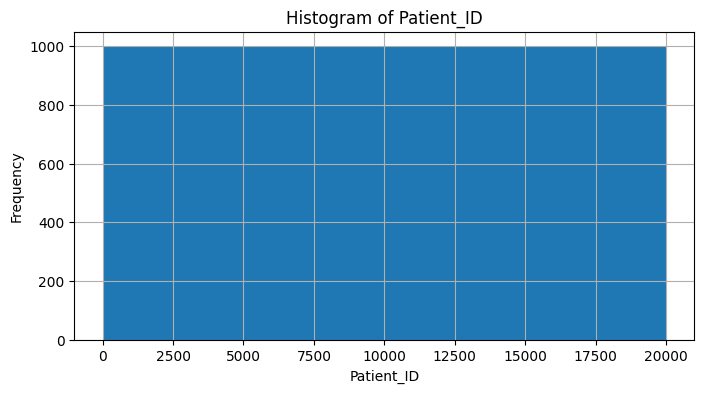

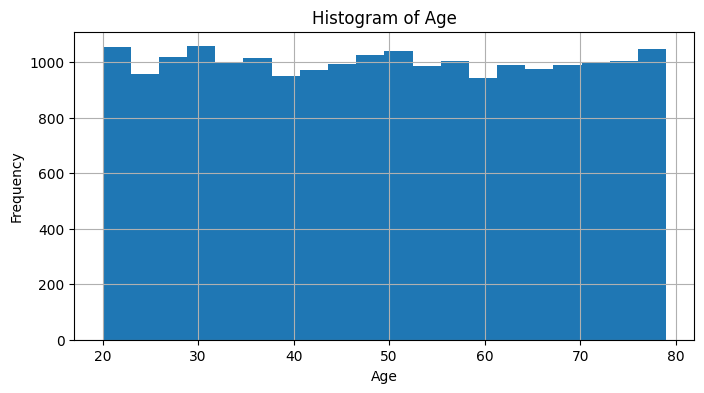

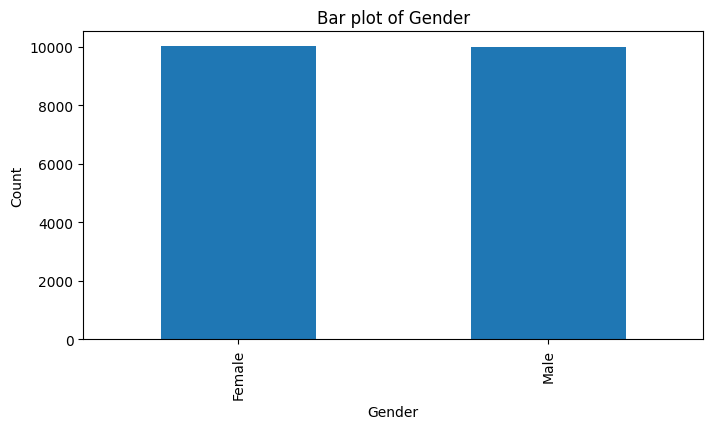

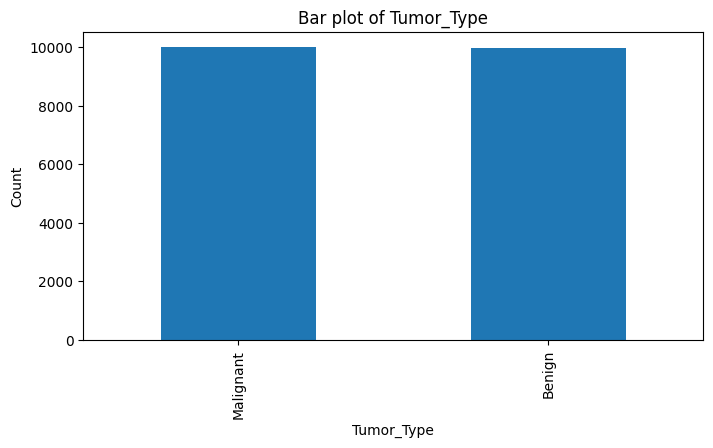

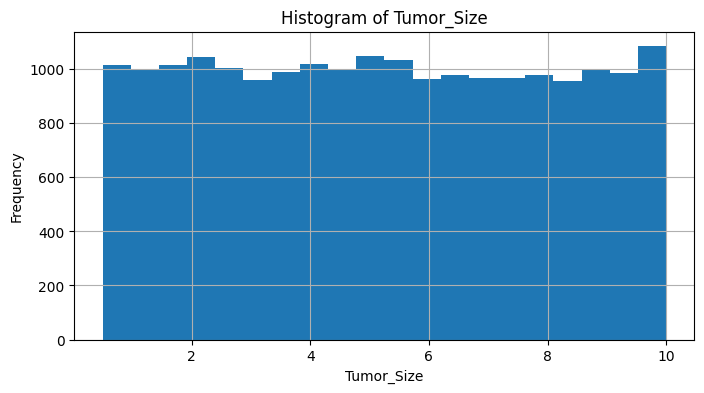

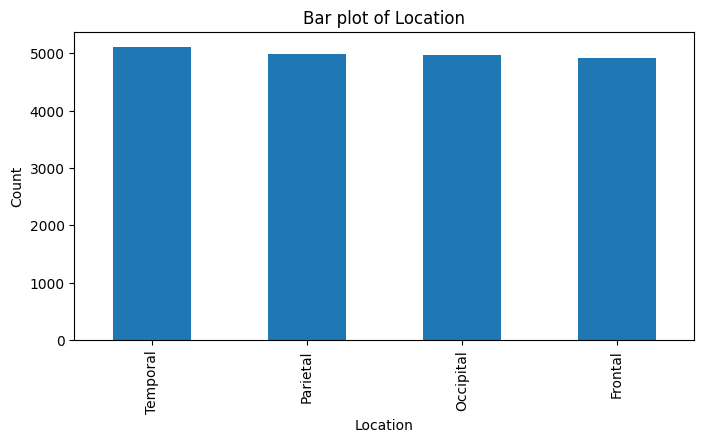

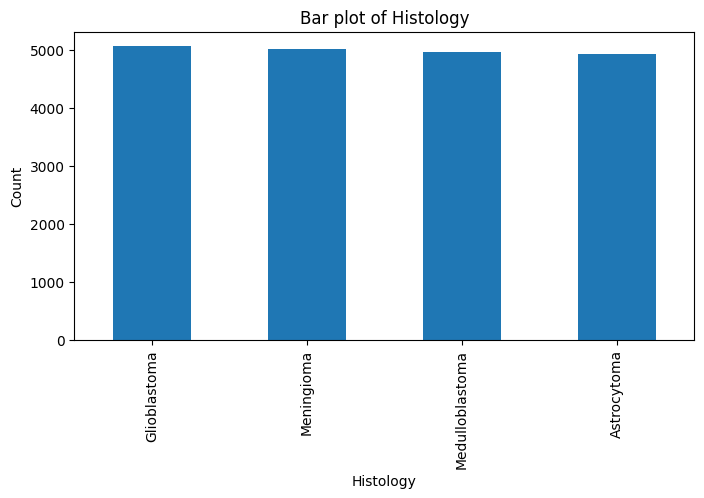

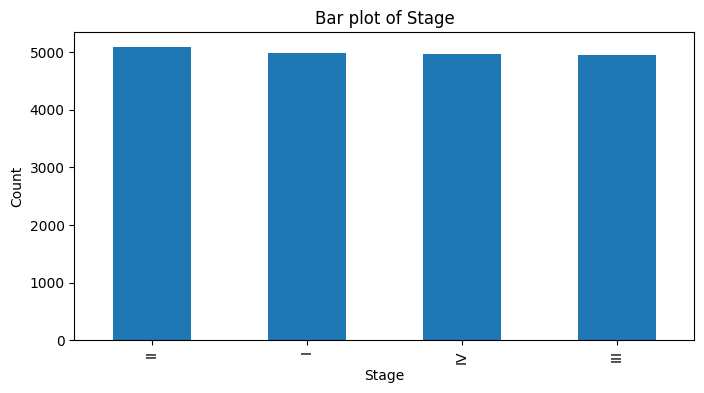

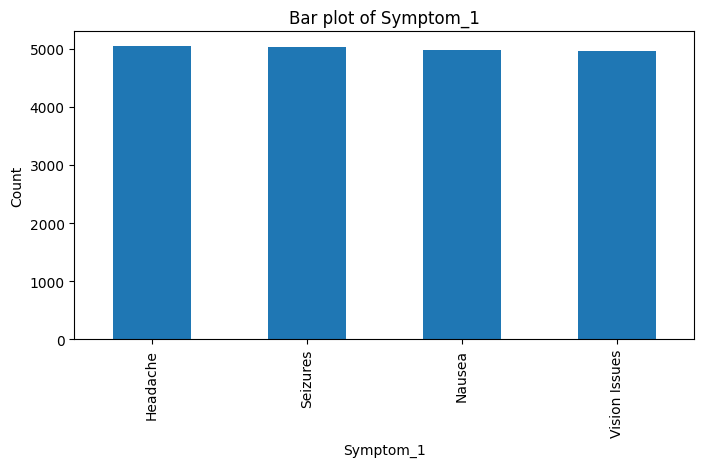

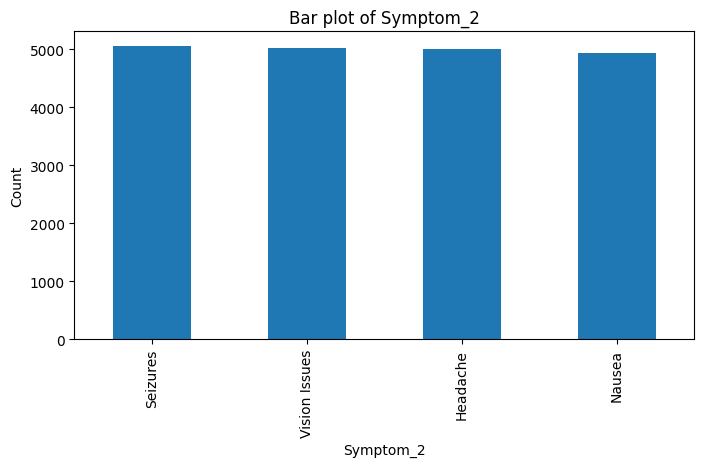

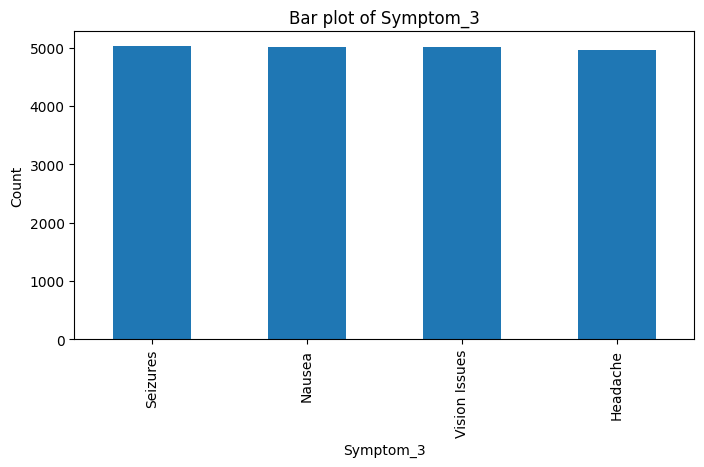

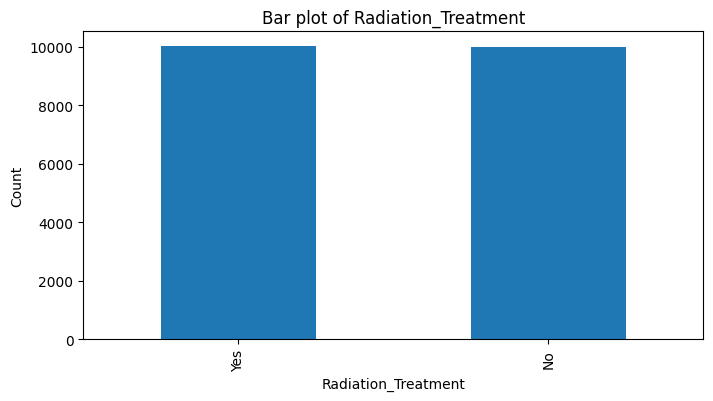

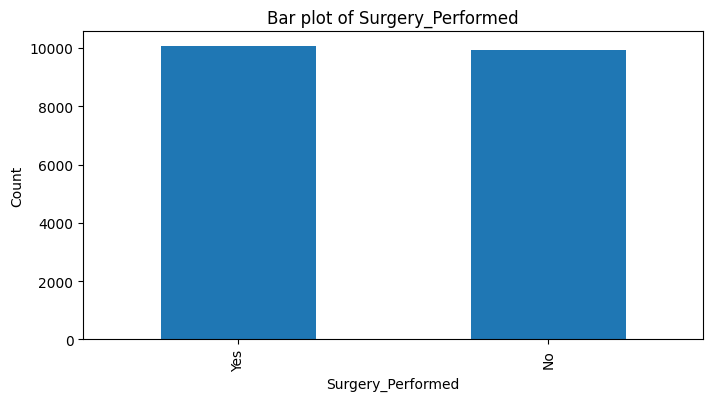

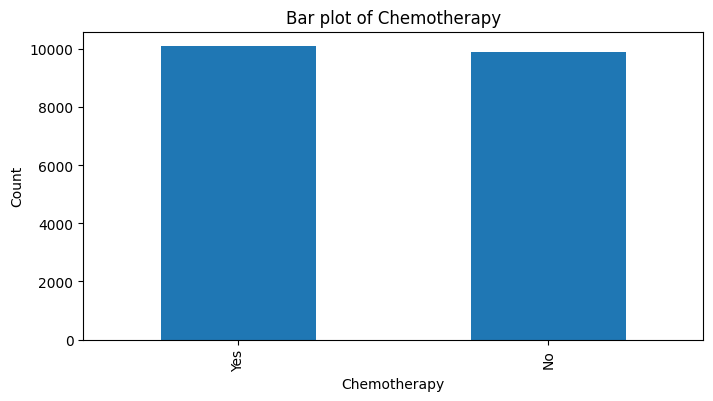

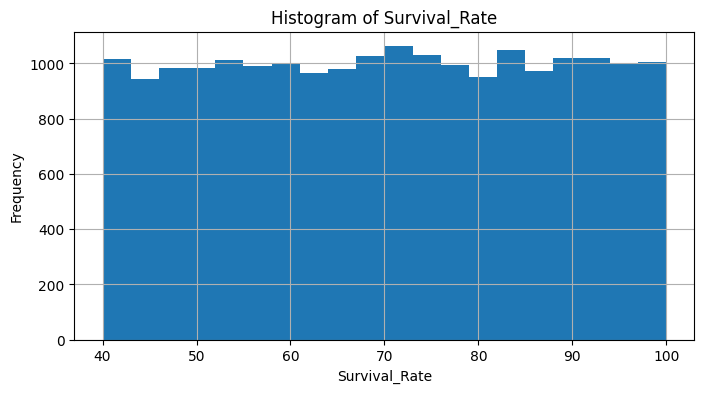

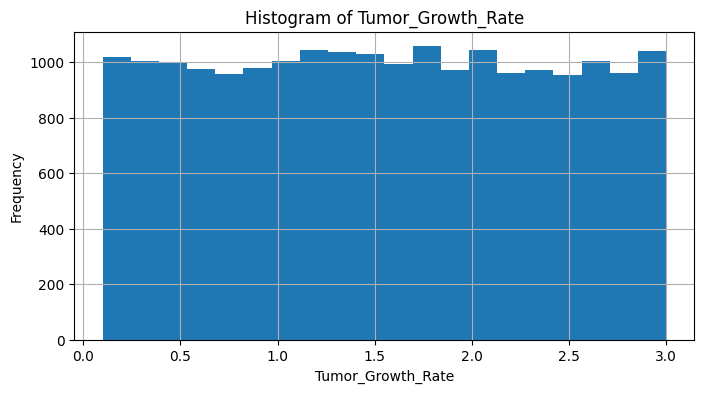

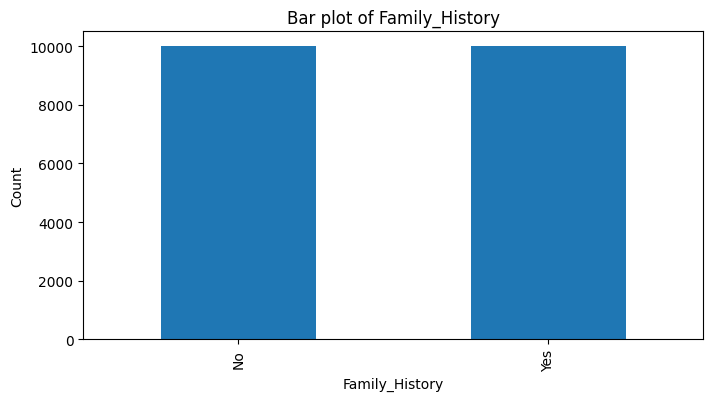

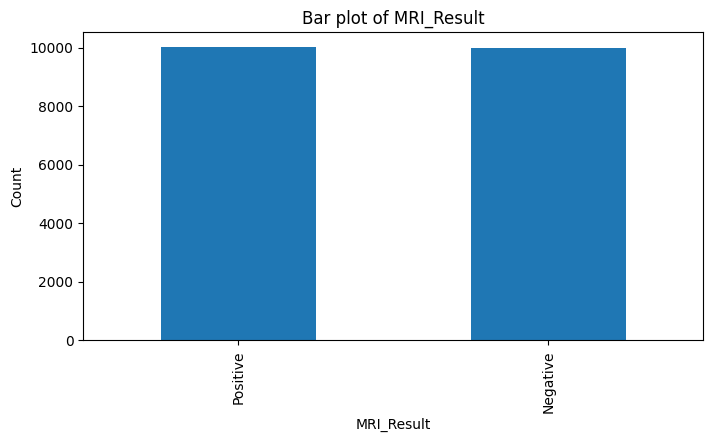

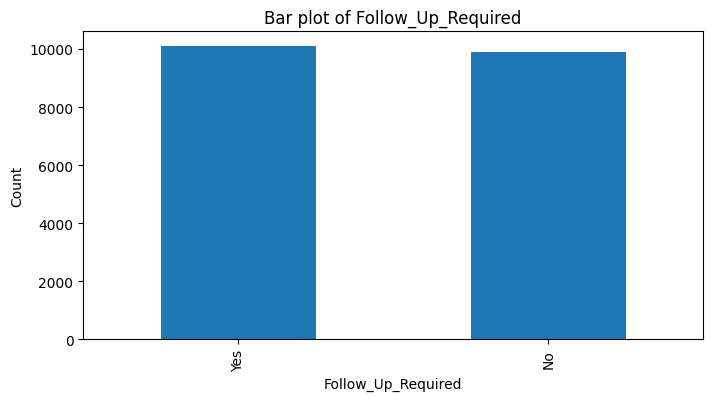

In [17]:
import matplotlib.pyplot as plt

for col in df.columns:
    plt.figure(figsize=(8, 4))
    if df[col].dtype in ['int64', 'float64']:
        df[col].hist(bins=20)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    else:
        df[col].value_counts().plot(kind='bar')
        plt.title(f'Bar plot of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
    plt.show()

In [18]:
mask_todos = ( 
    (df['Chemotherapy'] == 'Yes') & 
    (df['Radiation_Treatment'] == 'Yes') &
    (df['Surgery_Performed'] == 'Yes')
)
print("Proportion of patients who received all three treatments:", mask_todos.sum())

Proportion of patients who received all three treatments: 2590


### Escalamos y codificamos los datos dependiendo el tipo de dato que tenemos 

In [19]:
numerical = ['Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']
categorical = ['Gender', 'Chemotherapy', 'Radiation_Treatment', 'Surgery_Performed', 'Family_History', 'MRI_Result', 'Follow_Up_Required']

X = df.drop(columns=['Tumor_Type'])
y = df['Tumor_Type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(), categorical),
        ('label', OrdinalEncoder(), ['Stage'])
    ]
)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),('model', MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
])

pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred = pipeline.predict(X)

### Sacamos precission, Recall, y el F1 

In [21]:
from sklearn.metrics import precision_score, recall_score

y_pred = pipeline.predict(X)

print(y.unique())

precision = precision_score(y, y_pred, pos_label='Malignant')
recall = recall_score(y, y_pred, pos_label='Malignant')

f1 = (2 * precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

['Malignant' 'Benign']
Precision: 0.6150862508931305
Recall: 0.6007976071784646
F1: 0.6078579714530691
